# Winds (Part 2) - Cross-Section

## Wind Model Inset

### Global Importation

In [3]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


### Load Raw Data (Ensemble Pre-Interpolation) ($u$ Component)

In [4]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'
path_figure = f"/home/users/alvin_ch/figures/Multi-model/{model_short}/Winds/"
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-hist'
config_1 = 'r1i1p1f1'
var = 'ua'
sub1 = 'gn'
sub2 = 'v20240619'
file_list_1 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_1}_gn_185001-194912',
             f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_1}_gn_195001-201412']

files_ens_1 = {}
filetype = '.nc'
for expe in tqdm(file_list_1):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{sub1}/{sub2}/{expe}{filetype}")
    files_ens_1[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:04<00:00,  2.32s/it]


In [5]:
# Ensemble r2i1p1f1
config_2 = 'r2i1p1f1'
sub3 = 'v20241203'
file_list_2 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_195001-201412']

files_ens_2 = {}
for expe in tqdm(file_list_2):
    path_tmp = (f"{path}{esm_var}/{config_2}/{Table_ID}/{var}/{sub1}/{sub3}/{expe}{filetype}")
    files_ens_2[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00,  9.45it/s]


In [6]:
# Ensemble r3i1p1f1
config_3 = 'r3i1p1f1'
sub4 = 'v20241211'
file_list_3 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_195001-201412']

files_ens_3 = {}
for expe in tqdm(file_list_3):
    path_tmp = (f"{path}{esm_var}/{config_3}/{Table_ID}/{var}/{sub1}/{sub4}/{expe}{filetype}")
    files_ens_3[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00,  9.16it/s]


In [7]:
config_4 = 'r4i1p1f1'
sub5 = 'v20260623'
file_list_4 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_4}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_4}_gn_195001-201412']

files_ens_4 = {}
for expe in tqdm(file_list_4):
    path_tmp = (f"{path}{esm_var}/{config_4}/{Table_ID}/{var}/{sub1}/{sub5}/{expe}{filetype}")
    files_ens_4[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 14.45it/s]


### Load Raw Data (Ensemble Pre-Interpolation) ($v$ Component)

In [8]:
config_1 = 'r1i1p1f1'
var = 'va'
sub1 = 'gn'
sub2 = 'v20240619'
file_list_5 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_1}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_1}_gn_195001-201412']

files_ens_5 = {}
filetype = '.nc'
for expe in tqdm(file_list_5):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{sub1}/{sub2}/{expe}{filetype}")
    files_ens_5[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00,  5.65it/s]


In [9]:
# Ensemble r2i1p1f1
config_2 = 'r2i1p1f1'
sub3 = 'v20241203'
file_list_6 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_195001-201412']

files_ens_6 = {}
for expe in tqdm(file_list_6):
    path_tmp = (f"{path}{esm_var}/{config_2}/{Table_ID}/{var}/{sub1}/{sub3}/{expe}{filetype}")
    files_ens_6[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 12.11it/s]


In [10]:
# Ensemble r3i1p1f1
config_3 = 'r3i1p1f1'
sub4 = 'v20241211'
file_list_7 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_195001-201412']

files_ens_7 = {}
for expe in tqdm(file_list_7):
    path_tmp = (f"{path}{esm_var}/{config_3}/{Table_ID}/{var}/{sub1}/{sub4}/{expe}{filetype}")
    files_ens_7[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 12.74it/s]


In [11]:
config_4 = 'r4i1p1f1'
sub5 = 'v20260623'
file_list_8 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_4}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_4}_gn_195001-201412']

files_ens_8 = {}
for expe in tqdm(file_list_8):
    path_tmp = (f"{path}{esm_var}/{config_4}/{Table_ID}/{var}/{sub1}/{sub5}/{expe}{filetype}")
    files_ens_8[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 16.02it/s]


### Merge Pre-Interpolated Data

In [12]:
# Merge files of the same ensemble together.
# Implementation
def two_files_merge_ua(files_dict, file_list, ensemble_member):
    ds1 = files_dict[file_list[0]]
    ds2 = files_dict[file_list[1]]

    # Concatenate along time
    merged = xr.concat([ds1, ds2], dim="time")

    # Ensure data is computed before writing
    merged = merged.load()

    # Write actual data to disk
    merged.to_netcdf(f"{path_files}/{ensemble_member}_ua_time_merged.nc", mode='w')

In [13]:
# u-components
# r1i1p1f1
# two_files_merge_ua(files_ens_1, file_list_1, 'r1i1p1f1')

# r2i1p1f1
# two_files_merge_ua(files_ens_2, file_list_2, 'r2i1p1f1')

# r3i1p1f1
# two_files_merge_ua(files_ens_3, file_list_3, 'r3i1p1f1')

# r4i1p1f1
# two_files_merge_ua(files_ens_4, file_list_4, 'r4i1p1f1')

### Standardise Coordinates

In [14]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Filter Data

In [15]:
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"
filename = "ua_time_merged.nc"
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

time_merged_u = {}

for ens in ensemble_members:
    time_merged_u[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

In [16]:
time_and_space_filtered_u = {}

# Set extent
lonmin, lonmax = -20, 20
latmin, latmax = -5, 20
start_date, end_date = '1979-01-01', '2015-01-01'

for ens in ensemble_members:
    data = standardise_coordinates(time_merged_u[ens])
    data = data.sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax))
    time_and_space_filtered_u[ens] = data.sel(time=slice(start_date, end_date))
    # time_and_space_filtered_u[ens].to_netcdf(f"{path_files}/{ens}_ua_time_space_filtered.nc", mode='w')

In [17]:
time_and_space_filtered_u[ensemble_members[0]]

<xarray.Dataset> Size: 15MB
Dimensions:    (time: 432, bnds: 2, latitude: 21, longitude: 21, plev: 19)
Coordinates:
  * time       (time) object 3kB 1979-01-16 00:00:00 ... 2014-12-16 00:00:00
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * latitude   (latitude) float64 168B -5.0 -3.75 -2.5 -1.25 ... 17.5 18.75 20.0
  * longitude  (longitude) float64 168B -18.75 -16.88 -15.0 ... 15.0 16.88 18.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 7kB dask.array<chunksize=(432, 2), meta=np.ndarray>
    lat_bnds   (time, latitude, bnds) float64 145kB dask.array<chunksize=(432, 21, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, bnds) float64 145kB dask.array<chunksize=(432, 21, 2), meta=np.ndarray>
    ua         (time, plev, latitude, longitude) float32 14MB dask.array<chunksize=(432, 4, 19, 21), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2024-05-02T20:47:24Z
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    ...                    ...
    tracking_id:           GCMODELDEV/f479bf23-65fd-4186-aeea-62b796099309
    variable_id:           ua
    variable_name:         ua
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3

### Implementation 1a (Seasonal Mean, Over Time)

In [18]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

In [19]:
seas = 'MJJAS'
seas_avg_model_u = {}
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

for expe in ensemble_members:
    # u-component
    data_u = time_and_space_filtered_u[expe]
    seas_avg_model_u[expe] = seasonal_average_over_years_customed_MJJAS(data_u)
    seas_avg_model_u[expe] = seas_avg_model_u[expe].mean('year')

### Compute Zonal Mean

In [20]:
zonal_mean_u = {}

for ens in ensemble_members:
    data = seas_avg_model_u[ens]
    zonal_mean_u[ens] = data.mean('longitude')

In [21]:
zonal_mean_u[ensemble_members[0]]

<xarray.Dataset> Size: 2kB
Dimensions:   (latitude: 21, bnds: 2, plev: 19)
Coordinates:
  * plev      (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * latitude  (latitude) float64 168B -5.0 -3.75 -2.5 -1.25 ... 17.5 18.75 20.0
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (latitude, bnds) float64 336B dask.array<chunksize=(21, 2), meta=np.ndarray>
    lon_bnds  (bnds) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    ua        (plev, latitude) float32 2kB dask.array<chunksize=(4, 19), meta=np.ndarray>

### Compute Ensemble Mean

In [22]:
def compute_ensemble_mean(ensemble_list, data_dict, variable):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [23]:
climatology_ens_mean_u = compute_ensemble_mean(ensemble_members, zonal_mean_u, 'ua')
climatology_ens_mean_u

<xarray.DataArray 'ua' (plev: 19, latitude: 21)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(19, 21), dtype=float32, chunksize=(4, 19), chunktype=numpy.ndarray>
Coordinates:
  * plev      (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * latitude  (latitude) float64 168B -5.0 -3.75 -2.5 -1.25 ... 17.5 18.75 20.0

### Implementation 1a (Plot Cross Section)

In [24]:
def u_wind_cross_section(u_wind, cbar_label, palette, latmin, latmax, pmin, pmax,
                         title, Save, filename):

    fig = plt.figure(figsize=(10, 6), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1)

    # Ensure dimension order
    u_wind = u_wind.transpose('plev', 'latitude')

    lat = u_wind['latitude'].values
    pressure = u_wind['plev'].values / 100

    # Latitude-pressure grid
    lat2d, pressure2d = np.meshgrid(lat, pressure)

    # min_u = u_wind.min()
    # max_u = u_wind.max()
    
    # Colour levels
    levels = np.arange(-15, 15, 0.5)

    # Plot zonal wind
    contour = ax.contourf(lat2d, pressure2d, u_wind.values, levels=levels,
                          cmap=palette, extend='neither')

    # Add contour lines every 5 m/s
    contour_lines = ax.contour(lat2d, pressure2d, u_wind.values, levels=np.arange(-15, 15, 3),
                               colors='purple', linewidths=2.5)

    # Label contour lines
    ax.clabel(contour_lines, inline=True, fontsize=9, fmt='%d')
    
    ax.invert_yaxis()

    ax.set_xlim(latmin, latmax)
    ax.set_ylim(pmax, pmin)

    ax.set_xlabel('Latitude (°)', fontsize=10)
    ax.set_ylabel('Pressure Level (hPa)', fontsize=10)

    ax.tick_params(axis='both', labelsize=12)

    ax.set_title(title, fontsize=14)

    ax.grid(True, linestyle='--', alpha=0.5)

    # Colourbar
    cbar = fig.colorbar(contour, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=10)

    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

## Wind Observations Inset

### Load Raw Data ($u$ Component)

In [25]:
years_list = []
raw_all_u_data = {}

data_dir = '/home/users/pmonerie001/tempo/ERA5'

# There are 83 years in the ERA5 observations set.
for i in range(36):
    years_list.append(str(1979+i))

for yr in years_list:
    tmp_path = f'{data_dir}/U_{yr}.nc'
    raw_all_u_data[yr] = xr.open_mfdataset(f'{tmp_path}', combine='by_coords', use_cftime=True)

### Merge Data

In [26]:
def all_years_obs_files_merge(files_dict, file_list):

    assert len(files_dict) == len(file_list)

    ds = []
    
    for i in range(len(file_list)):
        ds.append(files_dict[file_list[i]])

    merged = xr.concat(ds, dim="valid_time")
    merged = merged.compute()
    
    merged.to_netcdf(f"{path_files}u_obs_all_years_time_merged.nc")
    merged.close()

In [27]:
# Merge files.
# all_years_obs_files_merge(raw_all_u_data, years_list)

### Load Merged Data

In [28]:
obs_all_plev_u_data = xr.open_dataset(f"{path_files}u_obs_all_years_time_merged.nc", use_cftime=True)
obs_all_plev_u_data

<xarray.Dataset> Size: 1GB
Dimensions:         (valid_time: 432, pressure_level: 19, latitude: 261,
                     longitude: 121)
Coordinates:
    number          int64 8B ...
  * valid_time      (valid_time) object 3kB 1979-01-01 00:00:00 ... 2014-12-0...
  * pressure_level  (pressure_level) float64 152B 1e+03 925.0 850.0 ... 5.0 1.0
  * latitude        (latitude) float64 2kB 45.0 44.75 44.5 ... -19.75 -20.0
  * longitude       (longitude) float64 968B -15.0 -14.75 -14.5 ... 14.75 15.0
    expver          (valid_time) <U4 7kB ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 1GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 30 22:20:02 2026: ncatted -O -a units,la...
    NCO:                     netCDF Operators version 5.3.3 (Homepage = http:...

### Standardise Coordinates

In [29]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Implementation 2a (Seasonal Mean)

In [30]:
def seasonal_average_over_years_MJJAS_obs(data):

    # Select May-September
    data_mjjas = data.sel(valid_time=data.valid_time.dt.month.isin([5, 6, 7, 8, 9]))

    # Create annual MJJAS averages
    seasonal_avg = data_mjjas.groupby('valid_time.year').mean('valid_time')
    return seasonal_avg

### Compute Seasonal Mean Over Time

In [31]:
seas = 'MJJAS'
seas_avg_obs = {}
obs_list = ['obs']

for expe in obs_list:
    obs_data = obs_all_plev_u_data
    seas_avg_obs['obs'] = seasonal_average_over_years_MJJAS_obs(obs_data).mean('year')

In [32]:
seas_avg_obs['obs']

<xarray.Dataset> Size: 2MB
Dimensions:         (pressure_level: 19, latitude: 261, longitude: 121)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 152B 1e+03 925.0 850.0 ... 5.0 1.0
  * latitude        (latitude) float64 2kB 45.0 44.75 44.5 ... -19.75 -20.0
  * longitude       (longitude) float64 968B -15.0 -14.75 -14.5 ... 14.75 15.0
Data variables:
    u               (pressure_level, latitude, longitude) float32 2MB 2.089 ....

### Compute Zonal Mean

In [33]:
zonal_mean_obs = {}

# Set extent
lonmin, lonmax = -20, 20

for expe in obs_list:
    data = seas_avg_obs[expe].sel(longitude=slice(lonmin, lonmax))
    zonal_mean_obs[expe] = data.mean('longitude')

In [34]:
zonal_mean_obs[expe]

<xarray.Dataset> Size: 22kB
Dimensions:         (pressure_level: 19, latitude: 261)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 152B 1e+03 925.0 850.0 ... 5.0 1.0
  * latitude        (latitude) float64 2kB 45.0 44.75 44.5 ... -19.75 -20.0
Data variables:
    u               (pressure_level, latitude) float32 20kB 0.2493 ... 17.08

### Implementation 2b (Plot Observations Cross Section)

In [35]:
def u_wind_cross_section_obs(u_wind, cbar_label, palette, latmin, latmax, pmin, pmax,
                             title, Save, filename):

    fig = plt.figure(figsize=(10, 6), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1)

    # Ensure dimension order
    u_wind = u_wind.transpose('pressure_level', 'latitude')

    lat = u_wind['latitude'].values
    pressure = u_wind['pressure_level'].values

    # Latitude-pressure grid
    lat2d, pressure2d = np.meshgrid(lat, pressure)

    # min_u = u_wind.min()
    # max_u = u_wind.max()
    
    # Colour levels
    levels = np.arange(-15, 15, 0.5)

    # Plot zonal wind
    contour = ax.contourf(lat2d, pressure2d, u_wind.values, levels=levels,
                          cmap=palette, extend='neither')

    # Add contour lines every 5 m/s
    contour_lines = ax.contour(lat2d, pressure2d, u_wind.values, levels=np.arange(-15, 15, 3),
                               colors='purple', linewidths=2.5)

    # Label contour lines
    ax.clabel(contour_lines, inline=True, fontsize=9, fmt='%d')
    
    ax.invert_yaxis()

    ax.set_xlim(latmin, latmax)
    ax.set_ylim(pmax, pmin)

    ax.set_xlabel('Latitude (°)', fontsize=10)
    ax.set_ylabel('Pressure Level (hPa)', fontsize=10)

    ax.tick_params(axis='both', labelsize=12)

    ax.set_title(title, fontsize=14)

    ax.grid(True, linestyle='--', alpha=0.5)

    # Colourbar
    cbar = fig.colorbar(contour, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=10)

    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

## Ensemble Mean Cross Section

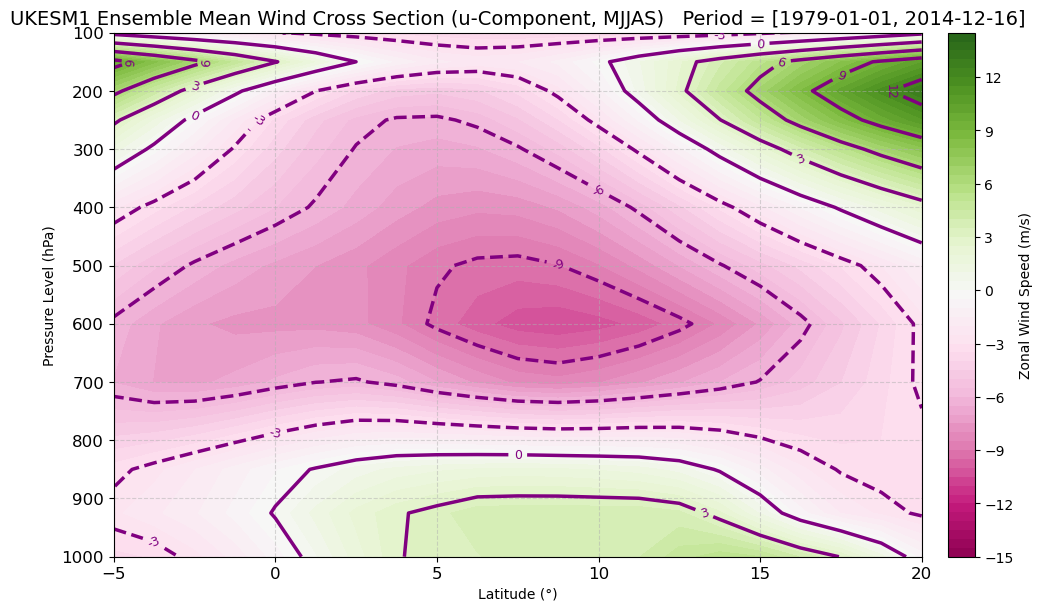

In [36]:
# Parameters
# Extent should be the same as before.
latmin = -5
latmax = 20

# Range should be the same as the dataset.
# Units in hPa
pmin = 100
pmax = 1000

# Colourbar
cbar_label = 'Zonal Wind Speed (m/s)'
palette = 'PiYG'

Save = True
title = 'UKESM1 Ensemble Mean Wind Cross Section (u-Component, MJJAS)   Period = [1979-01-01, 2014-12-16]'
filename = f'{path_figure}CS-Winds_u_Component_Ensemble_Mean.png'

u_wind_cross_section(climatology_ens_mean_u, cbar_label, palette, latmin, latmax, pmin, pmax,
                     title, Save, filename)

## Observations Cross Section

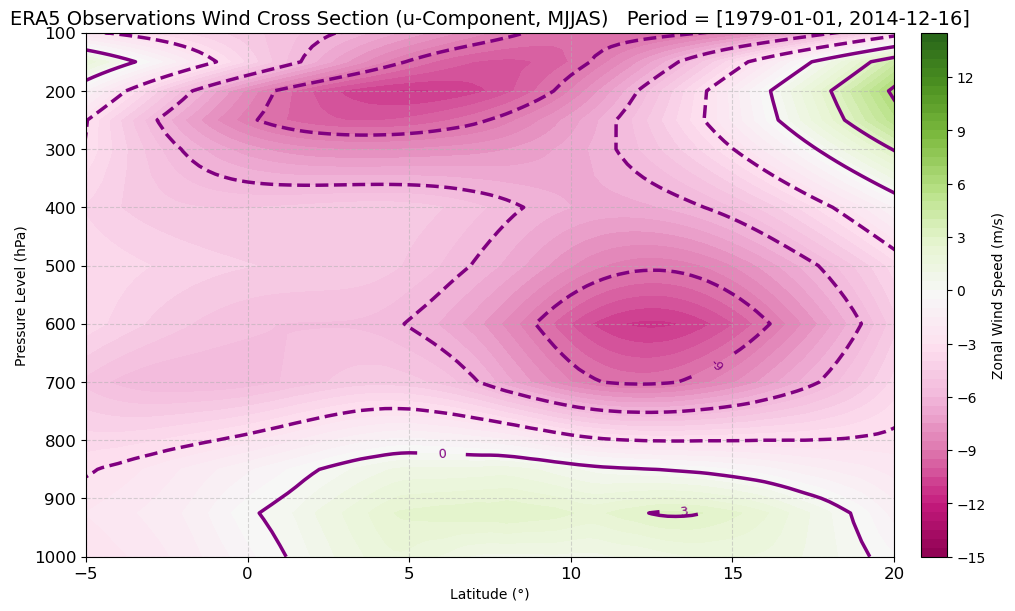

In [37]:
# Parameters
# Extent should be the same as before.
latmin = -5
latmax = 20

# Range should be the same as the dataset.
# Units in hPa
pmin = 100
pmax = 1000

# Colourbar
cbar_label = 'Zonal Wind Speed (m/s)'
palette = 'PiYG'

Save = True
title = 'ERA5 Observations Wind Cross Section (u-Component, MJJAS)   Period = [1979-01-01, 2014-12-16]'
filename = f'{path_figure}CS-Winds_u_Component_ERA5_Obs.png'

u_wind_cross_section_obs(zonal_mean_obs[expe]['u'], cbar_label, palette, latmin, latmax, pmin, pmax,
                         title, Save, filename)

## Bias Computation

In [38]:
time_and_space_filtered_u[ensemble_members[0]]

<xarray.Dataset> Size: 15MB
Dimensions:    (time: 432, bnds: 2, latitude: 21, longitude: 21, plev: 19)
Coordinates:
  * time       (time) object 3kB 1979-01-16 00:00:00 ... 2014-12-16 00:00:00
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * latitude   (latitude) float64 168B -5.0 -3.75 -2.5 -1.25 ... 17.5 18.75 20.0
  * longitude  (longitude) float64 168B -18.75 -16.88 -15.0 ... 15.0 16.88 18.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 7kB dask.array<chunksize=(432, 2), meta=np.ndarray>
    lat_bnds   (time, latitude, bnds) float64 145kB dask.array<chunksize=(432, 21, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, bnds) float64 145kB dask.array<chunksize=(432, 21, 2), meta=np.ndarray>
    ua         (time, plev, latitude, longitude) float32 14MB dask.array<chunksize=(432, 4, 19, 21), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2024-05-02T20:47:24Z
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    ...                    ...
    tracking_id:           GCMODELDEV/f479bf23-65fd-4186-aeea-62b796099309
    variable_id:           ua
    variable_name:         ua
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3

In [39]:
model_wind_dict = {}

# Extract common years.
common_years = obs_all_plev_u_data['valid_time'].dt.year.values

for ens in time_and_space_filtered_u:
    common_years = np.intersect1d(common_years, time_and_space_filtered_u[ens]['time'].dt.year.values)

# Select data corresponding to common years.
for ens in time_and_space_filtered_u:
    model_wind_dict[ens] = time_and_space_filtered_u[ens].sel(time=time_and_space_filtered_u[ens]['time'].dt.year.isin(common_years))

obs_wind = obs_all_plev_u_data.sel(valid_time=obs_all_plev_u_data['valid_time'].dt.year.isin(common_years))

### Compute Seasonal Mean Over Time

In [40]:
# Convert units first
for ens in model_wind_dict:
    model_wind_dict[ens] = model_wind_dict[ens].rename({'plev': 'pressure_level'})
    model_wind_dict[ens] = model_wind_dict[ens].assign_coords(pressure_level=model_wind_dict[ens]['pressure_level'] / 100)

# Compute MJJAS seasonal mean
model_seasonal_wind = {}

for ens in model_wind_dict:
    model_seasonal_wind[ens] = seasonal_average_over_years_customed_MJJAS(model_wind_dict[ens]).mean('year')

# Compute ensemble mean
ens_mean = compute_ensemble_mean(ensemble_members, model_seasonal_wind, 'ua')

# Observations
obs_seasonal_wind = seasonal_average_over_years_MJJAS_obs(obs_wind).mean('year')

# Calculate bias
bias = ens_mean - obs_seasonal_wind

In [41]:
bias

<xarray.Dataset> Size: 15kB
Dimensions:         (pressure_level: 19, latitude: 21, longitude: 9)
Coordinates:
  * pressure_level  (pressure_level) float64 152B 1e+03 925.0 850.0 ... 5.0 1.0
  * latitude        (latitude) float64 168B 20.0 18.75 17.5 ... -2.5 -3.75 -5.0
  * longitude       (longitude) float64 72B -15.0 -11.25 -7.5 ... 7.5 11.25 15.0
    number          int64 8B ...
Data variables:
    u               (pressure_level, latitude, longitude) float32 14kB dask.array<chunksize=(4, 10, 9), meta=np.ndarray>

### Compute Zonal Mean

In [42]:
# Set extent
lonmin, lonmax = -20, 20

bias_zonal_mean = bias.sel(longitude=slice(lonmin, lonmax)).mean('longitude')

In [43]:
bias_zonal_mean

<xarray.Dataset> Size: 2kB
Dimensions:         (pressure_level: 19, latitude: 21)
Coordinates:
  * pressure_level  (pressure_level) float64 152B 1e+03 925.0 850.0 ... 5.0 1.0
  * latitude        (latitude) float64 168B 20.0 18.75 17.5 ... -2.5 -3.75 -5.0
    number          int64 8B ...
Data variables:
    u               (pressure_level, latitude) float32 2kB dask.array<chunksize=(4, 10), meta=np.ndarray>

### Implementation 3a (Plot Bias Cross Section)

In [46]:
def u_wind_cross_section_bias(u_wind, obs_wind, cbar_label, palette, latmin, latmax, pmin, pmax,
                              title, Save, filename):

    fig = plt.figure(figsize=(10, 6), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1)

    ### BIAS ###
    
    # Ensure dimension order
    u_wind = u_wind.transpose('pressure_level', 'latitude')

    lat = u_wind['latitude'].values
    pressure = u_wind['pressure_level'].values

    # Latitude-pressure grid
    lat2d, pressure2d = np.meshgrid(lat, pressure)

    # min_u = u_wind.min()
    # max_u = u_wind.max()
    
    # Colour levels
    levels = np.arange(-10, 10, 0.2)

    # Plot zonal wind
    contour = ax.contourf(lat2d, pressure2d, u_wind.values, levels=levels,
                          cmap=palette, extend='neither')

    # Add contour lines every 5 m/s
    contour_lines = ax.contour(lat2d, pressure2d, u_wind.values, levels=np.arange(-10, 10, 2),
                               colors='black', linewidths=2.5)

    # Label contour lines
    ax.clabel(contour_lines, inline=True, fontsize=9, fmt='%d')

    ### OBSERVATION STIPPLING ###
    
    # Ensure dimension order
    obs_wind = obs_wind.transpose('pressure_level', 'latitude')

    lat = obs_wind['latitude'].values
    pressure = obs_wind['pressure_level'].values

    # Latitude-pressure grid
    lat2d, pressure2d = np.meshgrid(lat, pressure)

    # Create mask where obs_wind > 0
    sig_mask = obs_wind.values > 0
    hatch_mask = np.where(sig_mask, 1, np.nan)
    
    # Overlay stippling
    ax.pcolor(
        lat2d, pressure2d, hatch_mask,
        hatch='..',
        alpha=0.0,               
        edgecolor='none',
        zorder=3
    )
    
    ax.invert_yaxis()

    ax.set_xlim(latmin, latmax)
    ax.set_ylim(pmax, pmin)

    ax.set_xlabel('Latitude (°)', fontsize=10)
    ax.set_ylabel('Pressure Level (hPa)', fontsize=10)

    ax.tick_params(axis='both', labelsize=12)

    ax.set_title(title, fontsize=14)

    ax.grid(True, linestyle='--', alpha=0.5)

    # Colourbar
    cbar = fig.colorbar(contour, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=10)

    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

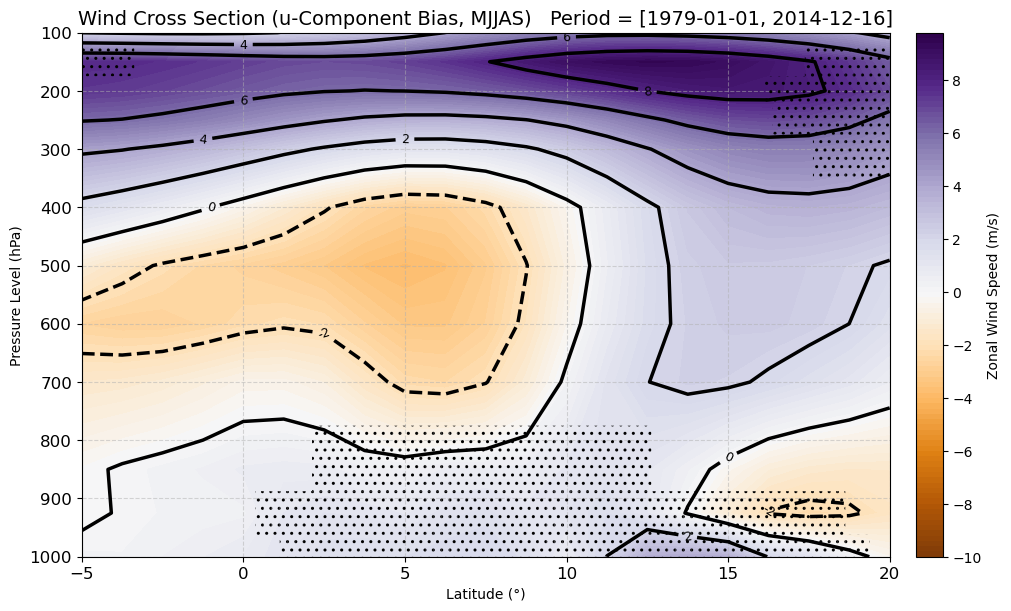

In [47]:
# Parameters
# Extent should be the same as before.
latmin = -5
latmax = 20

# Range should be the same as the dataset.
# Units in hPa
pmin = 100
pmax = 1000

# Colourbar
cbar_label = 'Zonal Wind Speed (m/s)'
palette = 'PuOr'

Save = True
title = 'Wind Cross Section (u-Component Bias, MJJAS)   Period = [1979-01-01, 2014-12-16]'
filename = f'{path_figure}CS-Winds_u_Component_bias.png'

u_wind_cross_section_bias(bias_zonal_mean['u'], zonal_mean_obs[expe]['u'], cbar_label, palette,
                          latmin, latmax, pmin, pmax, title, Save, filename)

### Final Figure

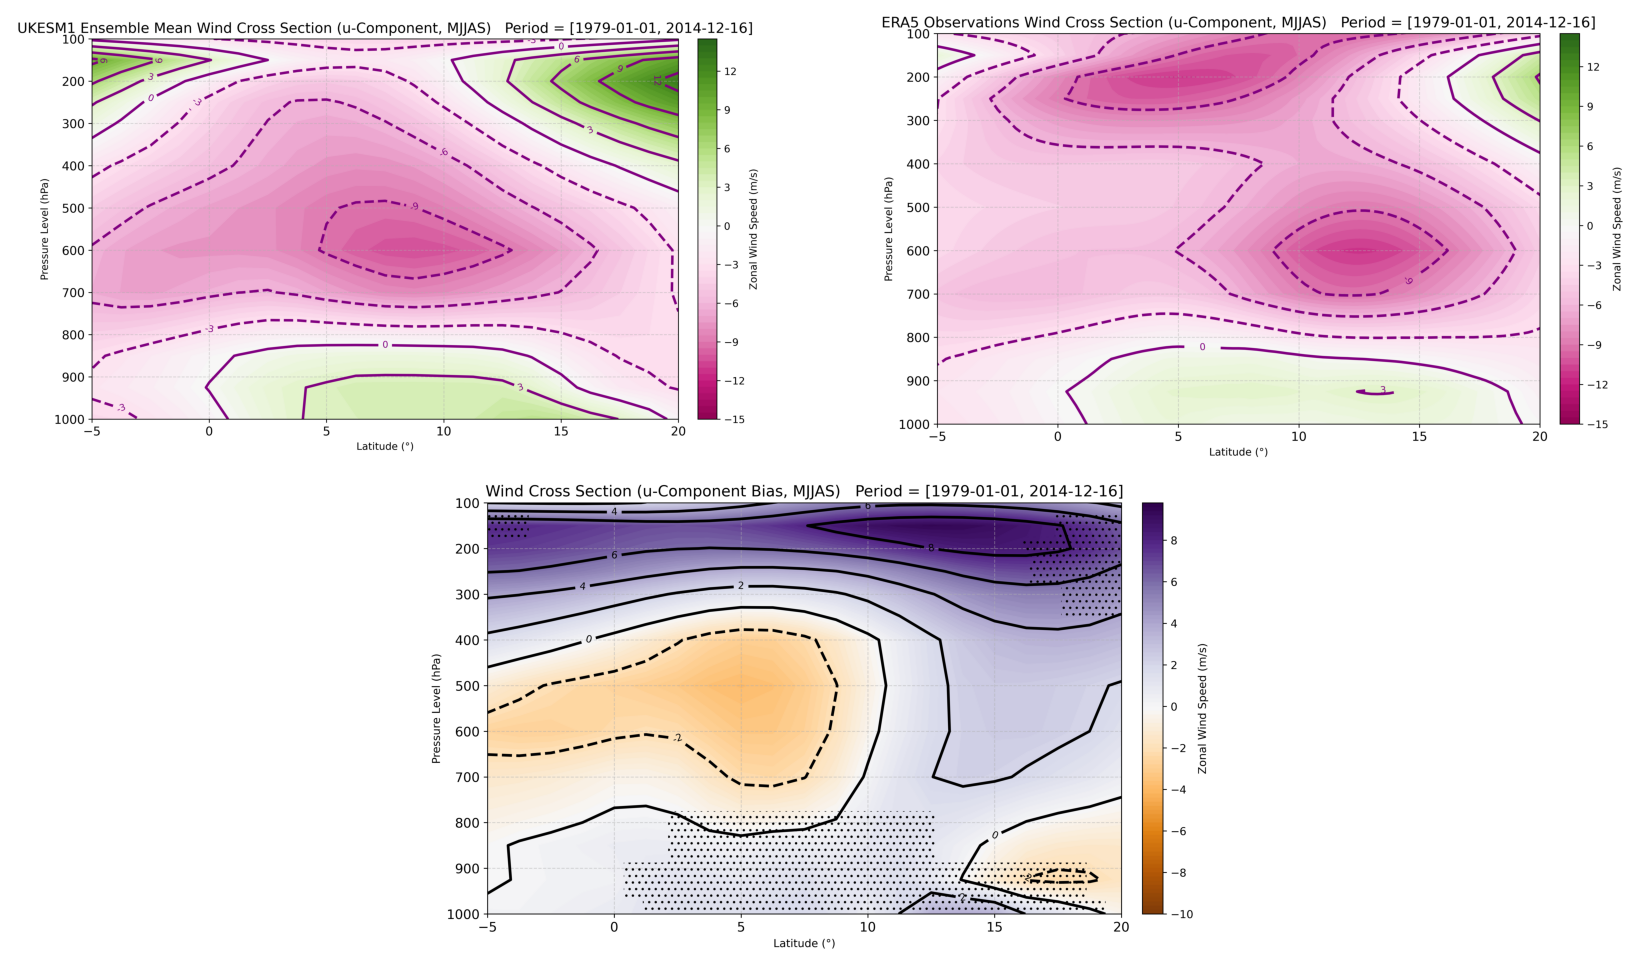

In [48]:
import matplotlib.image as mpimg

fig = plt.figure(figsize=(18, 12))

ax1 = fig.add_axes([0.05, 0.55, 0.42, 0.40])
ax1.imshow(mpimg.imread(f'{path_figure}CS-Winds_u_Component_Ensemble_Mean.png'))
ax1.axis("off")

ax2 = fig.add_axes([0.53, 0.55, 0.42, 0.40])
ax2.imshow(mpimg.imread(f"{path_figure}CS-Winds_u_Component_ERA5_Obs.png"))
ax2.axis("off")

ax3 = fig.add_axes([0.28, 0.15, 0.44, 0.40])
ax3.imshow(mpimg.imread(f'{path_figure}CS-Winds_u_Component_bias.png'))
ax3.axis("off")

plt.savefig(f"{path_figure}WAM_Cross-Section_Wind_Profile.png", bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show()